In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("/kaggle/input/competitions/playground-series-s3e1/train.csv")

print(df.head())

   id  MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0   0  2.3859      15.0  3.827160   1.112100      1280.0  2.486989     34.60   
1   1  3.7188      17.0  6.013373   1.054217      1504.0  3.813084     38.69   
2   2  4.7750      27.0  6.535604   1.103175      1061.0  2.464602     34.71   
3   3  2.4138      16.0  3.350203   0.965432      1255.0  2.089286     32.66   
4   4  3.7500      52.0  4.284404   1.069246      1793.0  1.604790     37.80   

   Longitude  MedHouseVal  
0    -120.12        0.980  
1    -121.22        0.946  
2    -120.45        1.576  
3    -117.09        1.336  
4    -122.41        4.500  


In [2]:
print("Размер:", df.shape)
df.info()

Размер: (37137, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37137 entries, 0 to 37136
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           37137 non-null  int64  
 1   MedInc       37137 non-null  float64
 2   HouseAge     37137 non-null  float64
 3   AveRooms     37137 non-null  float64
 4   AveBedrms    37137 non-null  float64
 5   Population   37137 non-null  float64
 6   AveOccup     37137 non-null  float64
 7   Latitude     37137 non-null  float64
 8   Longitude    37137 non-null  float64
 9   MedHouseVal  37137 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 2.8 MB


In [3]:
df.isna().sum()

id             0
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [4]:
target = "MedHouseVal"
X = df.drop(columns=[target, "id"], errors="ignore")
y = df[target]

print("Признаки:", X.columns.tolist())
print("Количество признаков:", X.shape[1])

Признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Количество признаков: 8


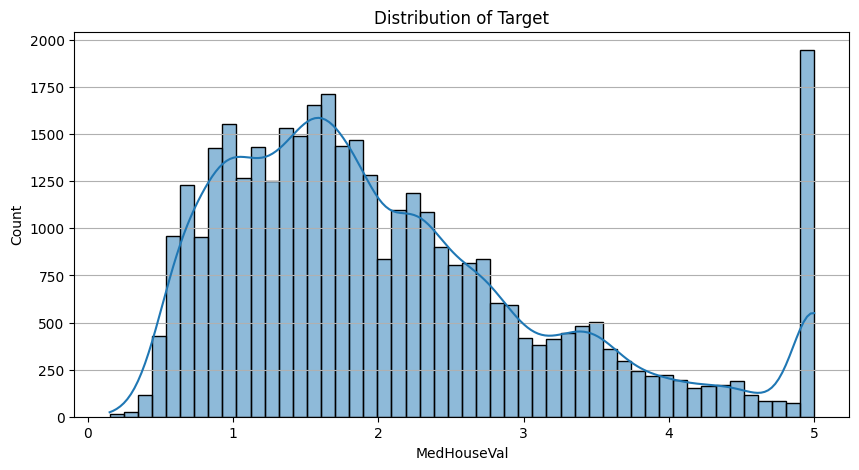

In [5]:
plt.figure(figsize=(10, 5))

sns.histplot(y, bins=50, kde=True)

plt.xlabel("MedHouseVal")
plt.ylabel("Count")
plt.title("Distribution of Target")
plt.grid(axis="y")
plt.show()

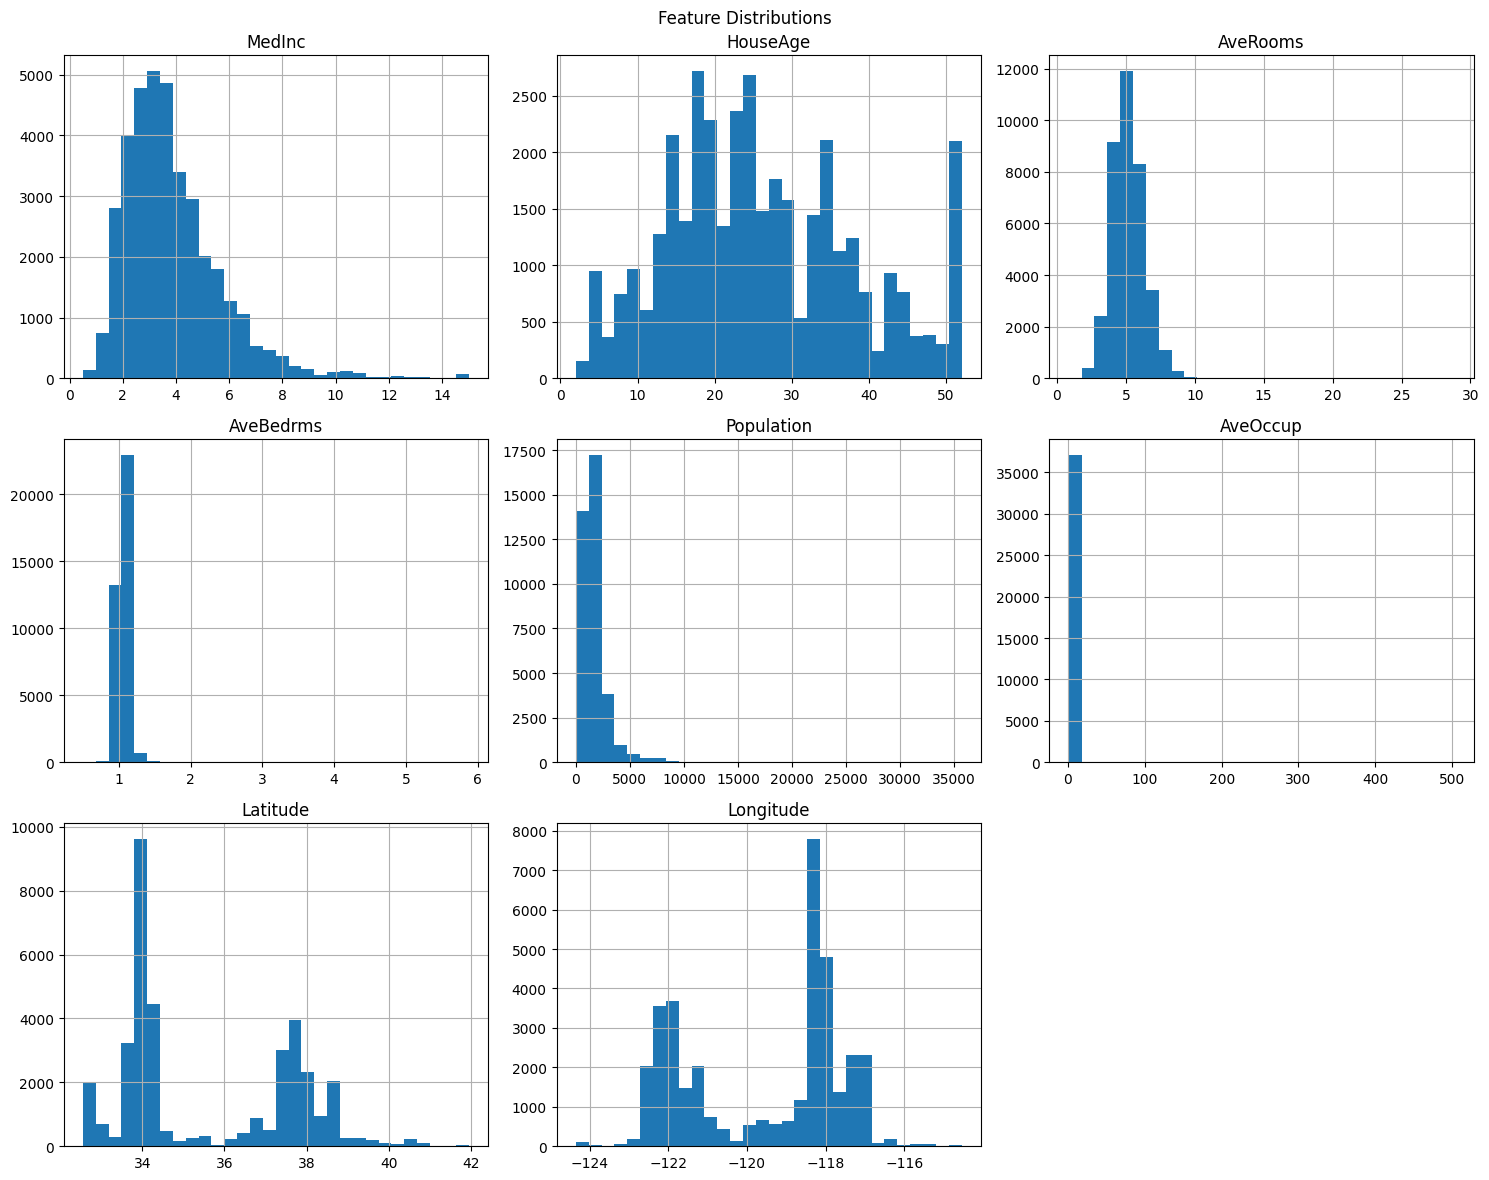

In [6]:
X.hist(figsize=(15, 12), bins=30)

plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

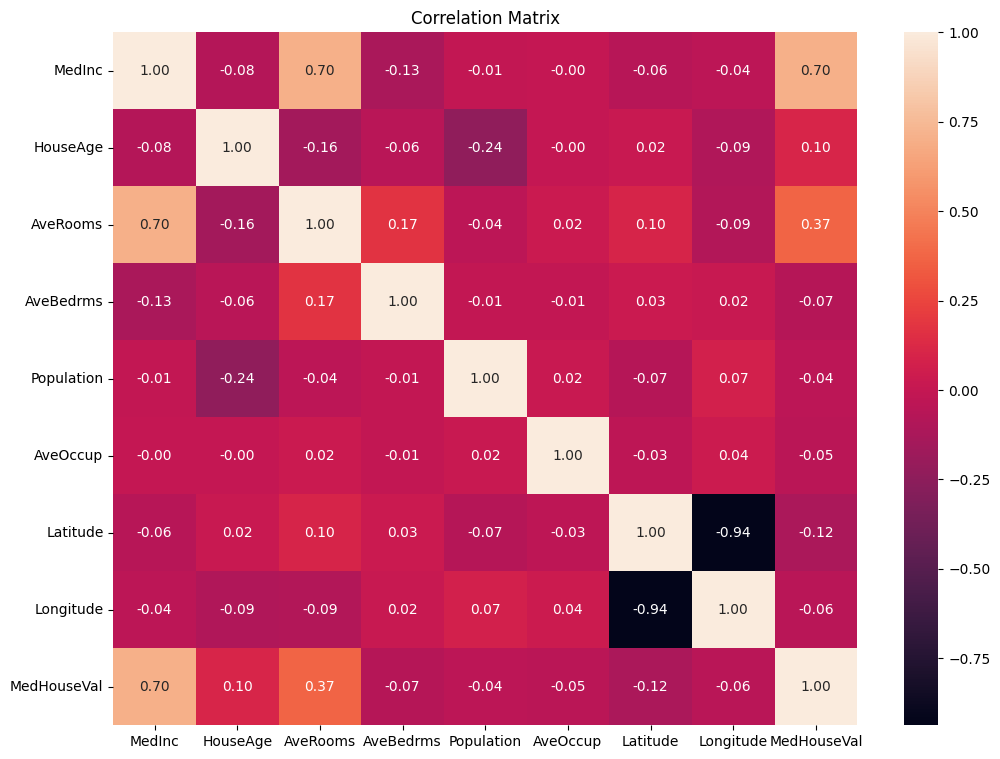

In [7]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    df.drop(columns="id", errors="ignore").corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

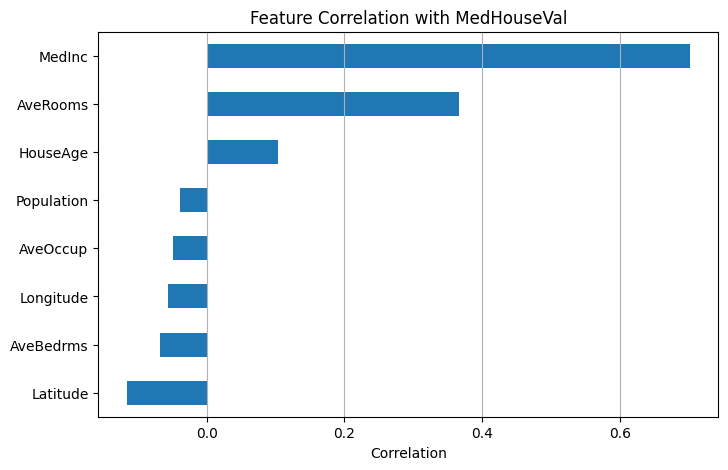

In [8]:
correlations = (
    df.drop(columns="id", errors="ignore")
    .corr()["MedHouseVal"]
    .sort_values()
)

plt.figure(figsize=(8, 5))

correlations.drop("MedHouseVal").plot(kind="barh")

plt.xlabel("Correlation")
plt.title("Feature Correlation with MedHouseVal")
plt.grid(axis="x")
plt.show()

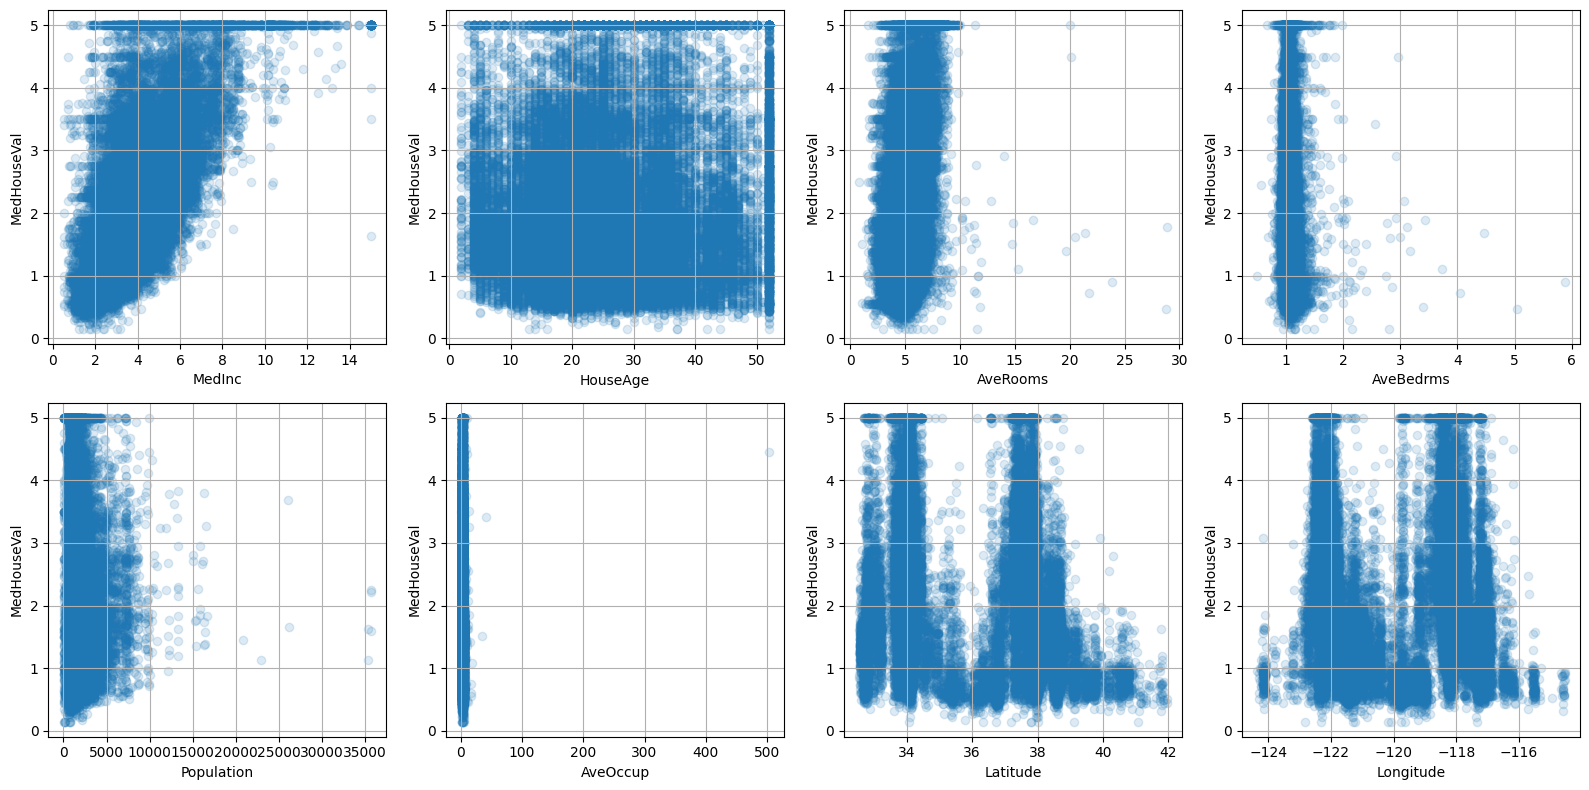

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, column in zip(axes.flat, X.columns):
    ax.scatter(X[column], y, alpha=0.15)
    ax.set_xlabel(column)
    ax.set_ylabel("MedHouseVal")
    ax.grid()

plt.tight_layout()
plt.show()

Сплит важно делать до скейлера, т.к. скейлер обучается на данных, и это небольшая, но утечка

Апдейт: вот сюда еще вставить удаление выбросов, потому что иначе пара кривых строчек ломают всю модель (я не заметила выбросы на графиках выше, это не означало, что их нет)

In [10]:
from scipy.stats import zscore

z_scores = np.abs(zscore(X))
mask = (z_scores < 3).all(axis=1)

X = X[mask]
y = y[mask]

print("После удаления выбросов:")
print("X:", X.shape)
print("y:", y.shape)
print("Удалено:", (~mask).sum())

После удаления выбросов:
X: (35497, 8)
y: (35497,)
Удалено: 1640


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (28397, 8)
Test: (7100, 8)


В задачу добавилось требование обучить baseline: модель, которая всегда предсказывает среднее значение.

In [12]:
def get_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred)
    }

In [13]:
baseline_value = y_train.mean()

y_test_baseline = np.full(len(y_test), baseline_value)

baseline_metrics = get_metrics(y_test, y_test_baseline)

print("=== Baseline ===")
print(f"Среднее значение target: {baseline_value:.4f}")
print(f"MAE:  {baseline_metrics['MAE']:.4f}")
print(f"MSE:  {baseline_metrics['MSE']:.4f}")
print(f"RMSE: {baseline_metrics['RMSE']:.4f}")
print(f"R²:   {baseline_metrics['R²']:.4f}")

=== Baseline ===
Среднее значение target: 2.0369
MAE:  0.8664
MSE:  1.2040
RMSE: 1.0973
R²:   -0.0002


In [14]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("regression", LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('regression', LinearRegression())])

In [15]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [16]:
results = pd.DataFrame({
    "Train": get_metrics(y_train, y_train_pred),
    "Test": get_metrics(y_test, y_test_pred)
})

results

,Train,Test
MAE,0.514823,0.502828
MSE,0.478038,0.462857
RMSE,0.691403,0.680336
R²,0.615961,0.615494


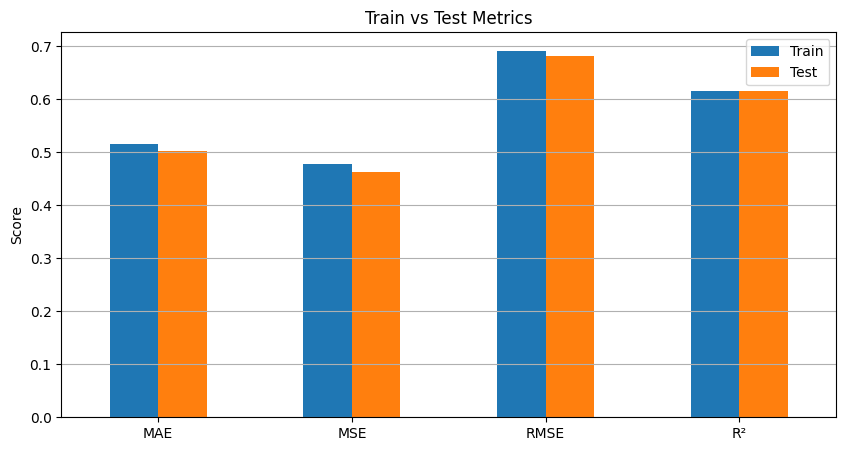

In [17]:
results.plot(kind="bar", figsize=(10, 5))

plt.title("Train vs Test Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

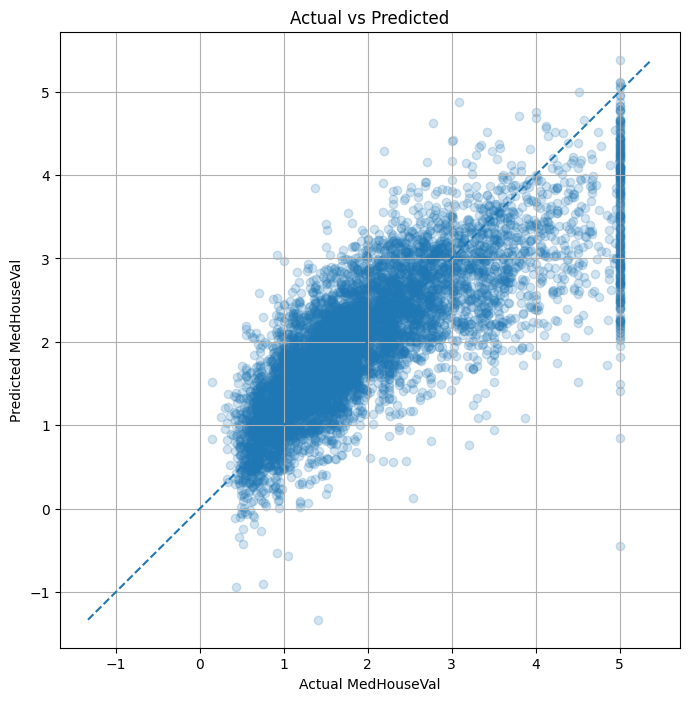

In [18]:
plt.figure(figsize=(8, 8))

plt.scatter(y_test, y_test_pred, alpha=0.2)

lims = [
    min(y_test.min(), y_test_pred.min()),
    max(y_test.max(), y_test_pred.max())
]

plt.plot(lims, lims, "--")

plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("Actual vs Predicted")
plt.grid()
plt.show()

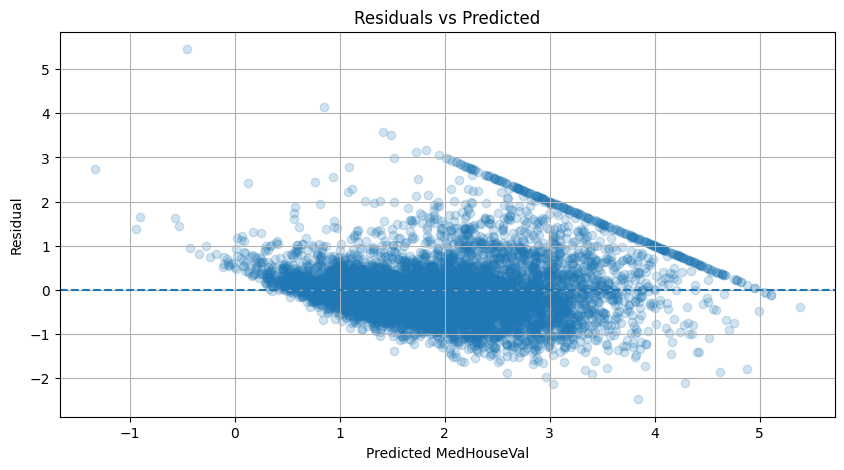

In [19]:
train_errors = y_train - y_train_pred
test_errors = y_test - y_test_pred

plt.figure(figsize=(10, 5))

plt.scatter(y_test_pred, test_errors, alpha=0.2)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted MedHouseVal")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.grid()
plt.show()

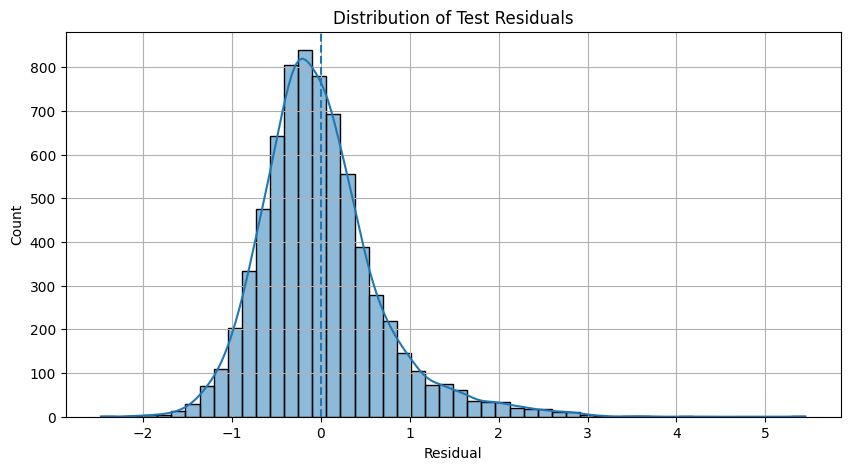

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(test_errors, bins=50, kde=True)

plt.axvline(0, linestyle="--")

plt.xlabel("Residual")
plt.title("Distribution of Test Residuals")
plt.grid()
plt.show()

Попробуем добавить кросс-валидацию

In [21]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "MSE": "neg_mean_squared_error",
        "RMSE": "neg_root_mean_squared_error",
        "R²": "r2"
    }
)

cv_results = pd.DataFrame({
    "MAE": -scores["test_MAE"],
    "MSE": -scores["test_MSE"],
    "RMSE": -scores["test_RMSE"],
    "R²": scores["test_R²"]
})



print(cv_results.head())

        MAE       MSE      RMSE        R²
0  0.502828  0.462857  0.680336  0.615494
1  0.511151  0.475345  0.689453  0.611221
2  0.515712  0.473472  0.688093  0.623185
3  0.515071  0.480176  0.692947  0.612819
4  0.516504  0.484467  0.696037  0.615279


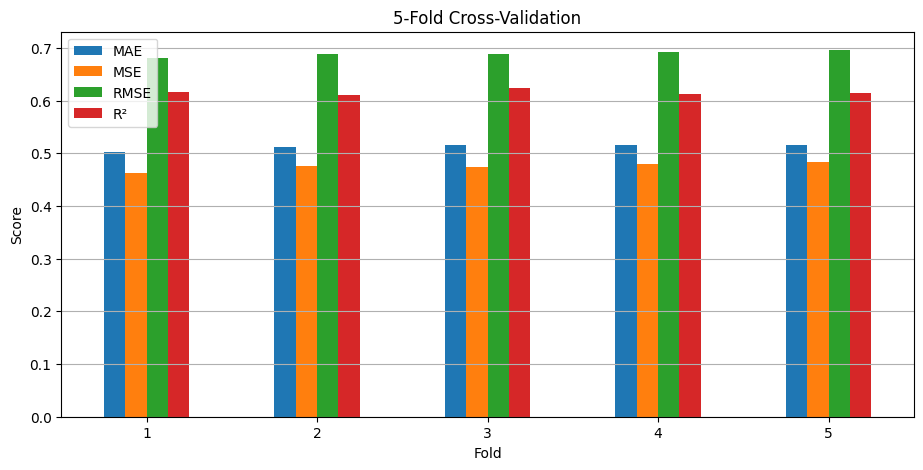

In [22]:
cv_results.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("5-Fold Cross-Validation")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.xticks(range(5), range(1, 6), rotation=0)
plt.grid(axis="y")
plt.show()

In [23]:
cv_summary = pd.DataFrame({
    "Mean": cv_results.mean(),
    "Std": cv_results.std()
})

print(cv_summary.head())

          Mean       Std
MAE   0.512253  0.005657
MSE   0.475263  0.008154
RMSE  0.689373  0.005926
R²    0.615599  0.004598


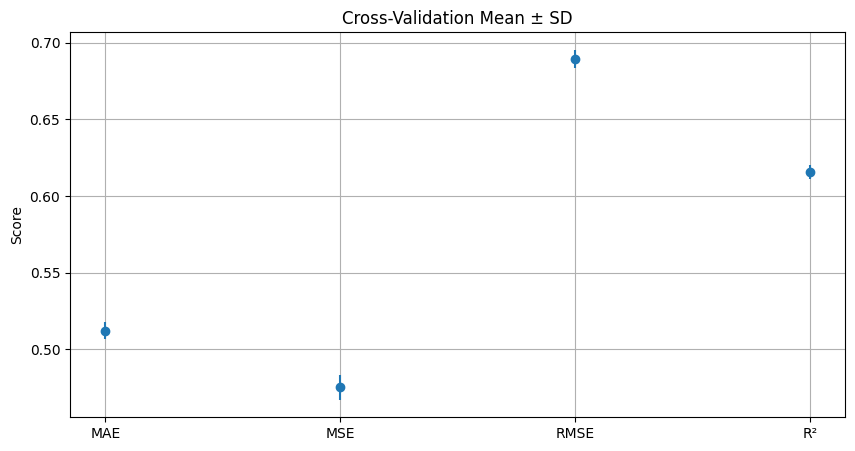

In [24]:
plt.figure(figsize=(10, 5))

plt.errorbar(
    cv_summary.index,
    cv_summary["Mean"],
    yerr=cv_summary["Std"],
    fmt="o"
)

plt.title("Cross-Validation Mean ± SD")
plt.ylabel("Score")
plt.grid()
plt.show()

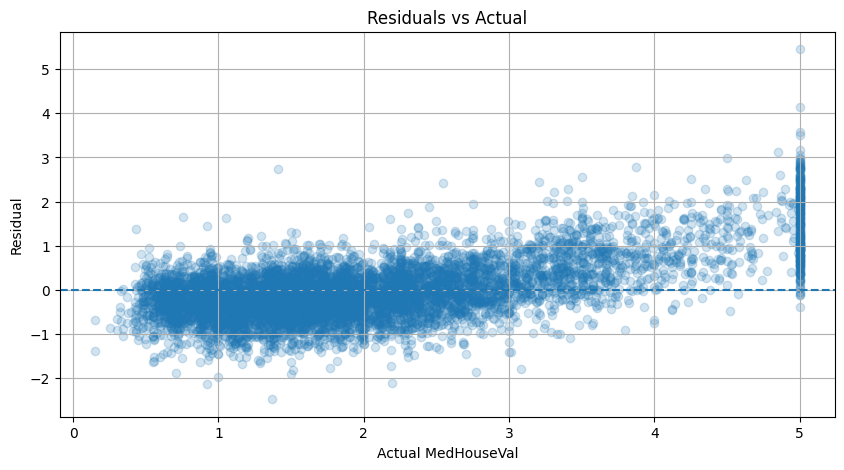

In [25]:
plt.figure(figsize=(10, 5))

plt.scatter(y_test, test_errors, alpha=0.2)
plt.axhline(0, linestyle="--")

plt.xlabel("Actual MedHouseVal")
plt.ylabel("Residual")
plt.title("Residuals vs Actual")
plt.grid()
plt.show()

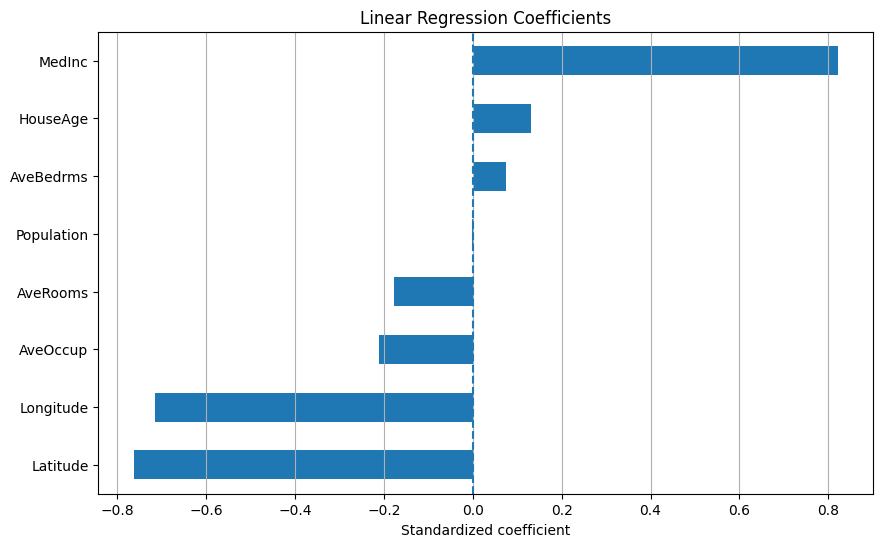

In [26]:
coefficients = pd.Series(
    model.named_steps["regression"].coef_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10, 6))

coefficients.plot(kind="barh")

plt.axvline(0, linestyle="--")

plt.xlabel("Standardized coefficient")
plt.title("Linear Regression Coefficients")
plt.grid(axis="x")
plt.show()

In [27]:
print("=== РЕЗУЛЬТАТЫ ДЛЯ ВЫВОДОВ ===\n")

final_results = pd.DataFrame({
    "Train": get_metrics(y_train, y_train_pred),
    "Test": get_metrics(y_test, y_test_pred),
    "CV mean": cv_results.mean(),
    "CV std": cv_results.std()
})

final_results.round(4)
#0. Метрики бейзлайна (всегда среднее значение)

print("=== Baseline ===")
print(f"Среднее значение target: {baseline_value:.4f}")
print(f"MAE:  {baseline_metrics['MAE']:.4f}")
print(f"MSE:  {baseline_metrics['MSE']:.4f}")
print(f"RMSE: {baseline_metrics['RMSE']:.4f}")
print(f"R²:   {baseline_metrics['R²']:.4f}")

# 1. Метрики
print("\n1. Метрики модели:")
print(final_results.round(4))

# 1.2 Сравнение модели и бейзлайна
print("\n1.2. Бейзлайн VS Метрики модели:")

comparison = pd.concat(
    [
        pd.Series(baseline_metrics, name="Baseline"),
        final_results["Test"].rename("Linear Regression")
    ],
    axis=1
).round(4)

print(comparison)

# 2. Разница Train/Test
print("\n2. Разница между Train и Test:")
for metric in ["MAE", "RMSE", "R²"]:
    diff = final_results.loc[metric, "Test"] - final_results.loc[metric, "Train"]
    print(f"{metric}: {diff:.4f}")

# 3. Cross-validation
print("\n3. Cross-validation:")
for metric in ["MAE", "RMSE", "R²"]:
    print(
        f"{metric}: "
        f"{cv_results[metric].mean():.4f} ± "
        f"{cv_results[metric].std():.4f}"
    )

# 4. Лучшие и худшие признаки по коэффициентам
print("\n4. Коэффициенты Linear Regression:")
print("Наибольшие по модулю:")
print(coefficients.abs().sort_values(ascending=False).head(5))

print("\nПоложительные:")
print(coefficients[coefficients > 0].sort_values(ascending=False).head(5))

print("\nОтрицательные:")
print(coefficients[coefficients < 0].sort_values().head(5))

# 5. Корреляции с target
print("\n5. Корреляция признаков с MedHouseVal:")
print(correlations.drop("MedHouseVal").sort_values().to_string())

# 6. Средняя абсолютная ошибка
print("\n6. Средняя ошибка:")
print(f"MAE = {final_results.loc['MAE', 'Test']:.4f}")

# 7. Итоговая информация
print("\n7. Итог:")
print(f"Размер train: {X_train.shape}")
print(f"Размер test:  {X_test.shape}")
print(f"Количество признаков: {X.shape[1]}")
print(f"R² на test: {final_results.loc['R²', 'Test']:.4f}")
print(f"RMSE на test: {final_results.loc['RMSE', 'Test']:.4f}")

=== РЕЗУЛЬТАТЫ ДЛЯ ВЫВОДОВ ===

=== Baseline ===
Среднее значение target: 2.0369
MAE:  0.8664
MSE:  1.2040
RMSE: 1.0973
R²:   -0.0002

1. Метрики модели:
       Train    Test  CV mean  CV std
MAE   0.5148  0.5028   0.5123  0.0057
MSE   0.4780  0.4629   0.4753  0.0082
RMSE  0.6914  0.6803   0.6894  0.0059
R²    0.6160  0.6155   0.6156  0.0046

1.2. Бейзлайн VS Метрики модели:
      Baseline  Linear Regression
MAE     0.8664             0.5028
MSE     1.2040             0.4629
RMSE    1.0973             0.6803
R²     -0.0002             0.6155

2. Разница между Train и Test:
MAE: -0.0120
RMSE: -0.0111
R²: -0.0005

3. Cross-validation:
MAE: 0.5123 ± 0.0057
RMSE: 0.6894 ± 0.0059
R²: 0.6156 ± 0.0046

4. Коэффициенты Linear Regression:
Наибольшие по модулю:
MedInc       0.822161
Latitude     0.763342
Longitude    0.715877
AveOccup     0.212063
AveRooms     0.176741
dtype: float64

Положительные:
MedInc       0.822161
HouseAge     0.130667
AveBedrms    0.075188
dtype: float64

Отрицательные:


Вывод: получена стабильная модель, не переобученная. Наибольшие коэффициенты у MedInc, Latitude и Longitude. Наибольшая корреляция с целевой переменной у MedInc (0.702), что довольно логично. Модель объясняет около 61.6% вариации стоимости жилья.

По распределению residuals видно, что ошибки растут линейно с увеличением стоимости жилья. Дорогое жилье вообще существует вопреки законам логики, ничего удивительного. Интересно, что для дешевого жилья тоже есть ошибка - но, наоборот, отрицательная. Модель завышает стоимость дешевого жилья и занижает стоимость дорогого. Т.е. наши данные в целом невозможно идеально описать линейной зависимостью.

Интересно, что возраст дома коррелирует с ценой положительно. Вроде как, должно быть наоборот.

НИЖЕ - НЕ АКТУАЛЬНОЕ! Траблшутинг: кросс-валидация показывала крайне нестабильные результаты. Выяснилось, что одна строчка с Average Occupancy 502 ломала всё. После удаления выбросов такое поведение прекратилось, и результаты в целом стали намного лучше. По-хорошему, надо бы задокументировать, насколько конкретно, но я не стала, т.к. учебная задача.

Что-то пошло очень сильно не так с кросс-валидацией.

In [28]:
print(cv_results)

        MAE       MSE      RMSE        R²
0  0.502828  0.462857  0.680336  0.615494
1  0.511151  0.475345  0.689453  0.611221
2  0.515712  0.473472  0.688093  0.623185
3  0.515071  0.480176  0.692947  0.612819
4  0.516504  0.484467  0.696037  0.615279


Один фолд портит всю картину. Посмотрим, что конкретно в нем.

In [29]:
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

for i, (_, val_idx) in enumerate(cv.split(X), 1):
    print(
        f"Fold {i}:",
        "min =", y.iloc[val_idx].min(),
        "max =", y.iloc[val_idx].max(),
        "mean =", y.iloc[val_idx].mean(),
        "std =", y.iloc[val_idx].std()
    )

Fold 1: min = 0.14999 max = 5.00001 mean = 2.022401474647887 std = 1.0972423096775152
Fold 2: min = 0.14999 max = 5.00001 mean = 2.0193857183098594 std = 1.1058177538003706
Fold 3: min = 0.225 max = 5.00001 mean = 2.0392964783772363 std = 1.1210202213314957
Fold 4: min = 0.14999 max = 5.00001 mean = 2.0418404888012396 std = 1.1137139829400153
Fold 5: min = 0.14999 max = 5.00001 mean = 2.047017000986054 std = 1.1222502458964692


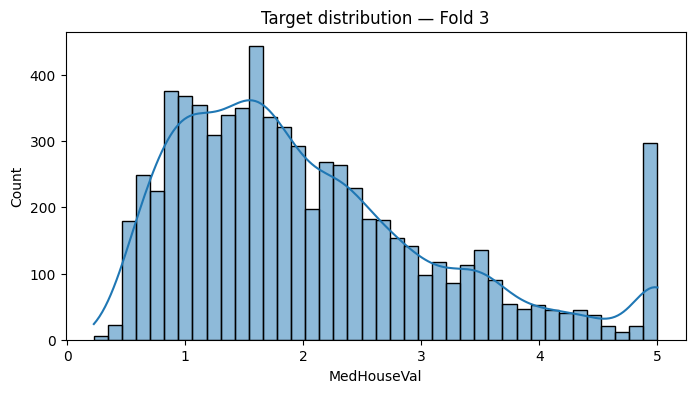

In [30]:
for i, (_, val_idx) in enumerate(cv.split(X), 1):
    if i == 3:
        plt.figure(figsize=(8, 4))
        sns.histplot(y.iloc[val_idx], bins=40, kde=True)
        plt.title("Target distribution — Fold 3")
        plt.xlabel("MedHouseVal")
        plt.show()

In [31]:
for i, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
    if i == 3:
        fold_model = model.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = fold_model.predict(X.iloc[val_idx])

        errors = pd.DataFrame({
            "Index": X.iloc[val_idx].index,
            "Actual": y.iloc[val_idx].values,
            "Predicted": pred,
        })

        errors["Error"] = errors["Actual"] - errors["Predicted"]
        errors["AbsError"] = errors["Error"].abs()

        print(errors.sort_values("AbsError", ascending=False).head(20))

      Index   Actual  Predicted     Error  AbsError
5607  29355  5.00001   0.633126  4.366884  4.366884
3089  16499  5.00001   0.973363  4.026647  4.026647
1587   8483  3.75000  -0.011155  3.761155  3.761155
182    1044  5.00001   1.539045  3.460965  3.460965
6404  33521  5.00001   1.824348  3.175662  3.175662
5281  27783  5.00001   1.953837  3.046173  3.046173
3771  19844  5.00000   1.968844  3.031156  3.031156
3305  17571  5.00001   2.022557  2.977453  2.977453
5496  28830  5.00001   2.070503  2.929507  2.929507
2947  15810  5.00001   2.158353  2.841657  2.841657
812    4447  5.00001   2.168765  2.831245  2.831245
2124  11368  5.00001   2.204310  2.795700  2.795700
1455   7794  5.00001   2.233065  2.766945  2.766945
1751   9371  5.00001   2.248574  2.751436  2.751436
1419   7541  5.00001   2.276803  2.723207  2.723207
897    4872  3.75000   1.058793  2.691207  2.691207
6383  33407  5.00001   2.311439  2.688571  2.688571
3097  16533  5.00001   2.317636  2.682374  2.682374
4222  22228 

Один объект все сломал. Что происходит?

In [32]:
# bad_idx = 18397

# check = pd.DataFrame({
#     "Value": X.loc[bad_idx],
#     "Mean": X.mean(),
#     "Std": X.std(),
#     "Min": X.min(),
#     "Max": X.max()
# })

# check["Z-score"] = (check["Value"] - check["Mean"]) / check["Std"]

# print(check.sort_values("Z-score", key=lambda x: x.abs(), ascending=False))

Я пропустила очистку выбросов. Получилось то, что получилось. Повезло, что, похоже, выброс всего один. Но почищу все: